# 01 — Field / Mode Profile Plots

2D 光场/模式场剖面图，支持两种绘制模式：
- **`scale='log'`, `cmap='inferno'`** — 发表级，对数强度
- **`scale='linear'`, `cmap='jet'`** — 快速查看原始数据

所有绘图均通过顶部 `plot_field_2d()` 统一函数实现。

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata

In [27]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

In [42]:
def plot_field_2d(data, x_vec, y_vec, *,
                  plane='XZ',
                  scale='log',
                  cmap='inferno',
                  title=None,
                  xlabel=None, ylabel=None,
                  cbar_label=r"|E|$^{2}$",
                  figsize=(8, 4),
                  aspect='equal',
                  vmin_frac=1e-5,
                  fontsize=14,
                  cbar_shrink=0.5,
                  dpi=100):
    """
    Plot a 2D field / mode profile.

    Parameters
    ----------
    data : 2D ndarray of shape (len(x_vec), len(y_vec))
    x_vec : 1D array — horizontal axis coordinates (μm)
    y_vec : 1D array — vertical axis coordinates (μm)
    plane : 'XZ', 'YZ', or 'XY'
    scale : 'log' -> LogNorm; 'linear' -> linear
    cmap : matplotlib colormap name
    title, xlabel, ylabel : str or None (auto-generated from plane)
    cbar_label : colorbar label
    figsize : figure size in inches
    aspect : 'equal', 'auto', or float
    vmin_frac : when scale='log', vmin = max(positive_min, vmax * vmin_frac)
    dpi : figure DPI
    """
    # ---- auto axis labels ----
    if xlabel is None or ylabel is None:
        _labels = {'XZ': ('X (μm)', 'Z (μm)'),
                   'YZ': ('Y (μm)', 'Z (μm)'),
                   'XY': ('X (μm)', 'Y (μm)')}
        _xl, _yl = _labels.get(plane, ('axis 1', 'axis 2'))
        if xlabel is None:
            xlabel = _xl
        if ylabel is None:
            ylabel = _yl

    X, Y = np.meshgrid(x_vec, y_vec, indexing='ij')

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    if scale == 'log':
        vmin = max(np.nanmin(data[data > 0]), vmin_frac * np.nanmax(data))
        vmax = np.nanmax(data)
        norm = LogNorm(vmin=vmin, vmax=vmax)
        pcm = ax.pcolormesh(X, Y, data, cmap=cmap, shading='auto', norm=norm)
        cbar = fig.colorbar(pcm, ax=ax, pad=0.02,
                            format=ticker.LogFormatterSciNotation())
    else:
        pcm = ax.pcolormesh(X, Y, data, cmap=cmap, shading='auto')
        cbar = fig.colorbar(pcm, ax=ax, pad=0.02)

    cbar.set_label(cbar_label, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    if title is not None:
        ax.set_title(title, fontsize=18)
    if aspect is not None:
        ax.set_aspect(aspect)

    fig.tight_layout()
    return fig, ax

In [43]:
def load_lumerical_field_2d(filename):
    """
    Load a 2D field data file exported by Lumerical.

    Parses the structured format:
      Line 1:     header (x position, wavelength)
      Line 3-:    y coordinate grid
      Line 148-:  z coordinate grid
      Line 233:   second header + data dimensions
      Line 234-:  field data (ny rows x nz cols, whitespace-delimited)

    Parameters
    ----------
    filename : str

    Returns
    -------
    data : 2D ndarray  shape (ny, nz) — |E| or field intensity
    y_vec : 1D ndarray  length ny — y-axis coordinates (m to um)
    z_vec : 1D ndarray  length nz — z-axis coordinates (m to um)
    """
    with open(filename, 'r') as f:
        lines = f.readlines()

    # ---- locate data block ----
    data_start = None
    ny, nz = None, None
    for i, line in enumerate(lines):
        if line.startswith("Field Data:") and '(' in line and ')' in line:
            # e.g. "Field Data: Re(E) vs position, ... (143,83)"
            dims = line.split('(')[-1].split(')')[0].split(',')
            if len(dims) == 2:
                ny, nz = int(dims[0].strip()), int(dims[1].strip())
                data_start = i + 1
                break

    if data_start is None:
        raise ValueError(f"Could not find 'Field Data: ... (ny,nz)' header in {filename}")

    # ---- parse field data ----
    data_lines = []
    for line in lines[data_start:]:
        parts = line.strip().split()
        if len(parts) == nz:
            data_lines.append(np.fromstring(line, sep=' '))
        elif len(parts) > 0:
            data_lines.append(np.fromstring(line, sep=' '))

    data = np.array(data_lines)
    if data.shape != (ny, nz):
        raise ValueError(f"Data shape {data.shape} != expected ({ny}, {nz})")

    # ---- parse y grid (after first 'y(m)' marker) ----
    y_values = []
    y_start = None
    for i, line in enumerate(lines):
        if line.strip().startswith('y(m)'):
            y_start = i + 1
            break
    if y_start is not None:
        for i in range(y_start, y_start + ny):
            try:
                y_values.append(float(lines[i].strip().split()[0]))
            except ValueError:
                break

    # ---- parse z grid (after first 'z(m)' marker) ----
    z_values = []
    z_start = None
    for i, line in enumerate(lines):
        if line.strip().startswith('z(m)'):
            z_start = i + 1
            break
    if z_start is not None:
        for i in range(z_start, z_start + nz):
            try:
                z_values.append(float(lines[i].strip().split()[0]))
            except ValueError:
                break

    y_vec = np.array(y_values) * 1e6  # m -> um
    z_vec = np.array(z_values) * 1e6  # m -> um

    if len(y_vec) != ny:
        raise ValueError(f"Parsed y points ({len(y_vec)}) != ny ({ny})")
    if len(z_vec) != nz:
        raise ValueError(f"Parsed z points ({len(z_vec)}) != nz ({nz})")

    return data, y_vec, z_vec

## 坐标边界预设

按仿真场景选择对应的 `x/y/z_min/max`：

In [30]:
# ---- r 场景 ----
x_min, x_max = -10, 270
y_min, y_max = -7,   7
z_min, z_max = -7,   7

In [31]:
# ---- d1 场景 ----
x_min, x_max = 0, 120
y_min, y_max = -4,   4
z_min, z_max = -4,   4

In [32]:
# ---- d2 场景 ----
x_min, x_max = 0, 80
y_min, y_max = -8,  8
z_min, z_max = -8,  8

## 示例

In [ ]:
# XZ 截面 — linear + jet
filename = r"D:\Desktop\WYC_files\PWBSimulation\SOA-PWB-SOA\data\transmission"
data, x, z = load_lumerical_field_2d(filename)

plot_field_2d(data, x, z, plane='XZ', scale='linear', cmap='jet',
              title="Field |E| — XZ Plane (linear)",
              figsize=(9, 3), aspect='auto')

In [ ]:
# XZ 截面 — log + inferno
plot_field_2d(Ex, x, z, plane='XZ', scale='log', cmap='inferno',
              title="Field |E| — XZ Plane (log)",
              figsize=(9, 3), aspect='auto')

### 3. SOA 源模式 YZ 截面 (log + inferno)

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'SOA Fundamental TE Mode — Source (@ 1550 nm)'}, xlabel='Y (μm)', ylabel='Z (μm)'>)

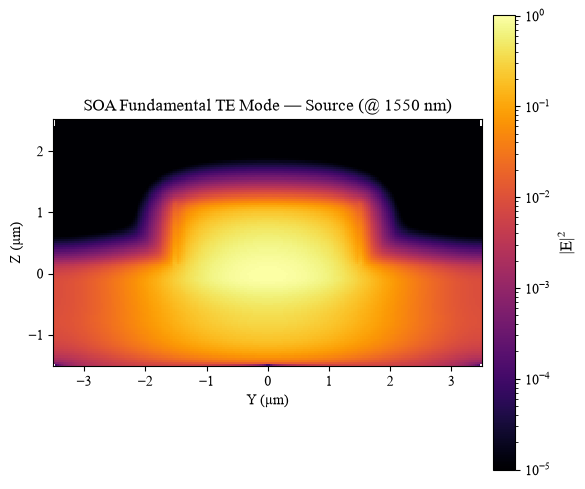

In [ ]:
# SOA source mode — YZ plane
# Uses load_lumerical_field_2d() to parse Lumerical's structured export format
data, y, z = load_lumerical_field_2d(r"../SOA-PWB-SOA/data/PG-source.txt")

plot_field_2d(data, y, z, plane='YZ', scale='log', cmap='inferno',
              title="SOA Fundamental TE Mode — Source (@ 1550 nm)",
              figsize=(6, 5))

### 4. SOA 输出监视器 YZ 截面 (linear + inferno)

(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': 'PE-SOA  @ 1550 nm'}, xlabel='Y (μm)', ylabel='Z (μm)'>)

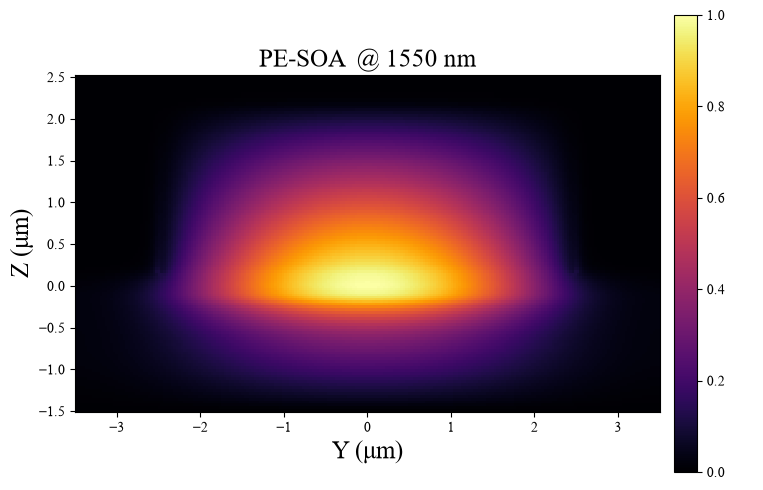

In [46]:
# SOA output monitor — YZ plane (linear + inferno)
# Reuses data, y, z from the previous cell
data, y, z = load_lumerical_field_2d(r"../SOA-PWB-SOA/data/PE-source.txt")
plot_field_2d(data, y, z, plane='YZ', scale='linear', cmap='inferno',
              title="PE-SOA  @ 1550 nm",
              cbar_label=" ",
              figsize=(8, 5))

### 5. 三角网格强度热图（带镜像对称）

这是一个特殊场景：从三角形网格数据插值并做镜像对称。保留原有逻辑。

In [ ]:
# 读取数据文件
filepath = r"D:/Wechat Files/WeChat Files/wxid_umtzlz2f1fad22/FileStorage/File/2025-06/Wave Intensity.txt"
with open(filepath, 'r') as f:
    lines = f.readlines()

# 解析数据
triangles = []
for i in range(2, len(lines)):
    line = lines[i].strip().split()
    if len(line) == 4:
        x, y, z, intensity = map(float, line)
        triangles.append([x, y, z, intensity])

triangles = np.array(triangles).reshape(-1, 3, 4)

# 去重顶点数据
unique_points = {}
for tri in triangles:
    for vertex in tri:
        key = (vertex[0], vertex[1], vertex[2])
        if key not in unique_points or unique_points[key][3] < vertex[3]:
            unique_points[key] = vertex

points = np.array(list(unique_points.values()))

x_coords = points[:, 0]
y_coords = points[:, 1]
x_min_v, x_max_v = min(x_coords), max(x_coords)
y_min_v, y_max_v = min(y_coords), max(y_coords)

# 创建完整网格（考虑对称性）
x_grid = np.linspace(-x_max_v, x_max_v, 200)
y_grid = np.linspace(y_min_v, y_max_v, 200)
X, Y = np.meshgrid(x_grid, y_grid)

# 插值
interp_points = points[:, [0, 1]]
interp_values = points[:, 3]

Z_original = griddata(interp_points, interp_values, (X, Y), method='linear', fill_value=0)

mirrored_points = np.copy(interp_points)
mirrored_points[:, 0] = -mirrored_points[:, 0]
Z_mirrored = griddata(mirrored_points, interp_values, (X, Y), method='linear', fill_value=0)
Z = Z_original + Z_mirrored

# ---- 绘图 ----
x_rng = 4 - (-4)    # x 范围
y_rng = 3 - 0        # y 范围
fig, ax = plt.subplots(figsize=(x_rng / 1.2, y_rng / 1.2))

pcm = ax.pcolormesh(X, Y, Z, shading='auto', cmap='jet', vmin=0, vmax=Z.max())
cbar = fig.colorbar(pcm, ax=ax, label='Intensity', shrink=0.95)
cbar.set_label('Intensity', fontsize=18)
cbar.ax.tick_params(labelsize=12)

ax.set_xlabel('X (μm)', fontsize=18)
ax.set_ylabel('Y (μm)', fontsize=18)
ax.set_title('Intensity (mirror-symmetric)', fontsize=18)
ax.tick_params(labelsize=12)
ax.set_xlim(-4, 4)
ax.set_ylim(0, 3)
ax.set_aspect('equal')

fig.tight_layout()
plt.show()